# Movie Rating Prediction and Model Comparison
This notebook analyzes the movie dataset from `mymoviedb (1).csv`, performs exploratory data analysis (EDA), applies preprocessing, trains three regression models, and compares their performance using multiple metrics.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

sns.set(style='whitegrid', font_scale=1.1)
DATA_PATH = 'mymoviedb (1).csv'
df = pd.read_csv(DATA_PATH, engine='python')
print('Dataset shape:', df.shape)
df.head(8)

Dataset shape: (9837, 9)


,Release_Date,Title,Overview,Popularity,Vote_Count,Vote_Average,Original_Language,Genre,Poster_Url
0,2021-12-15,Spider-Man: No Way Home,Peter Parker is unmasked and no longer able to...,5083.954,8940,8.3,en,"Action, Adventure, Science Fiction",https://image.tmdb.org/t/p/original/1g0dhYtq4i...
1,2022-03-01,The Batman,"In his second year of fighting crime, Batman u...",3827.658,1151,8.1,en,"Crime, Mystery, Thriller",https://image.tmdb.org/t/p/original/74xTEgt7R3...
2,2022-02-25,No Exit,Stranded at a rest stop in the mountains durin...,2618.087,122,6.3,en,Thriller,https://image.tmdb.org/t/p/original/vDHsLnOWKl...
3,2021-11-24,Encanto,"The tale of an extraordinary family, the Madri...",2402.201,5076,7.7,en,"Animation, Comedy, Family, Fantasy",https://image.tmdb.org/t/p/original/4j0PNHkMr5...
4,2021-12-22,The King's Man,As a collection of history's worst tyrants and...,1895.511,1793,7.0,en,"Action, Adventure, Thriller, War",https://image.tmdb.org/t/p/original/aq4Pwv5Xeu...
5,2022-01-07,The Commando,An elite DEA agent returns home after a failed...,1750.484,33,6.6,en,"Action, Crime, Thriller",https://image.tmdb.org/t/p/original/pSh8MyYu5C...
6,2022-01-12,Scream,Twenty-five years after a streak of brutal mur...,1675.161,821,6.8,en,"Horror, Mystery, Thriller",https://image.tmdb.org/t/p/original/kZNHR1upJK...
7,2022-02-10,Kimi,A tech worker with agoraphobia discovers recor...,1601.782,206,6.3,en,Thriller,https://image.tmdb.org/t/p/original/okNgwtxIWz...


In [2]:
print('Columns:', list(df.columns))
print('\nMissing values by column:')
print(df.isna().sum())
print('\nSample dtypes:')
print(df.dtypes)
print('\nUnique language count:', df['Original_Language'].nunique())
print('Unique genre count:', df['Genre'].nunique())

Columns: ['Release_Date', 'Title', 'Overview', 'Popularity', 'Vote_Count', 'Vote_Average', 'Original_Language', 'Genre', 'Poster_Url']

Missing values by column:
Release_Date          0
Title                 9
Overview              9
Popularity           10
Vote_Count           10
Vote_Average         10
Original_Language    10
Genre                11
Poster_Url           11
dtype: int64

Sample dtypes:
Release_Date          object
Title                 object
Overview              object
Popularity           float64
Vote_Count            object
Vote_Average          object
Original_Language     object
Genre                 object
Poster_Url            object
dtype: object

Unique language count: 44
Unique genre count: 2337


## Exploratory Data Analysis (EDA)
The target variable is `Vote_Average`, representing the average rating for each movie. We will explore distributions, missing data, language and genre frequencies, and the relationship between popularity, vote count, and rating.

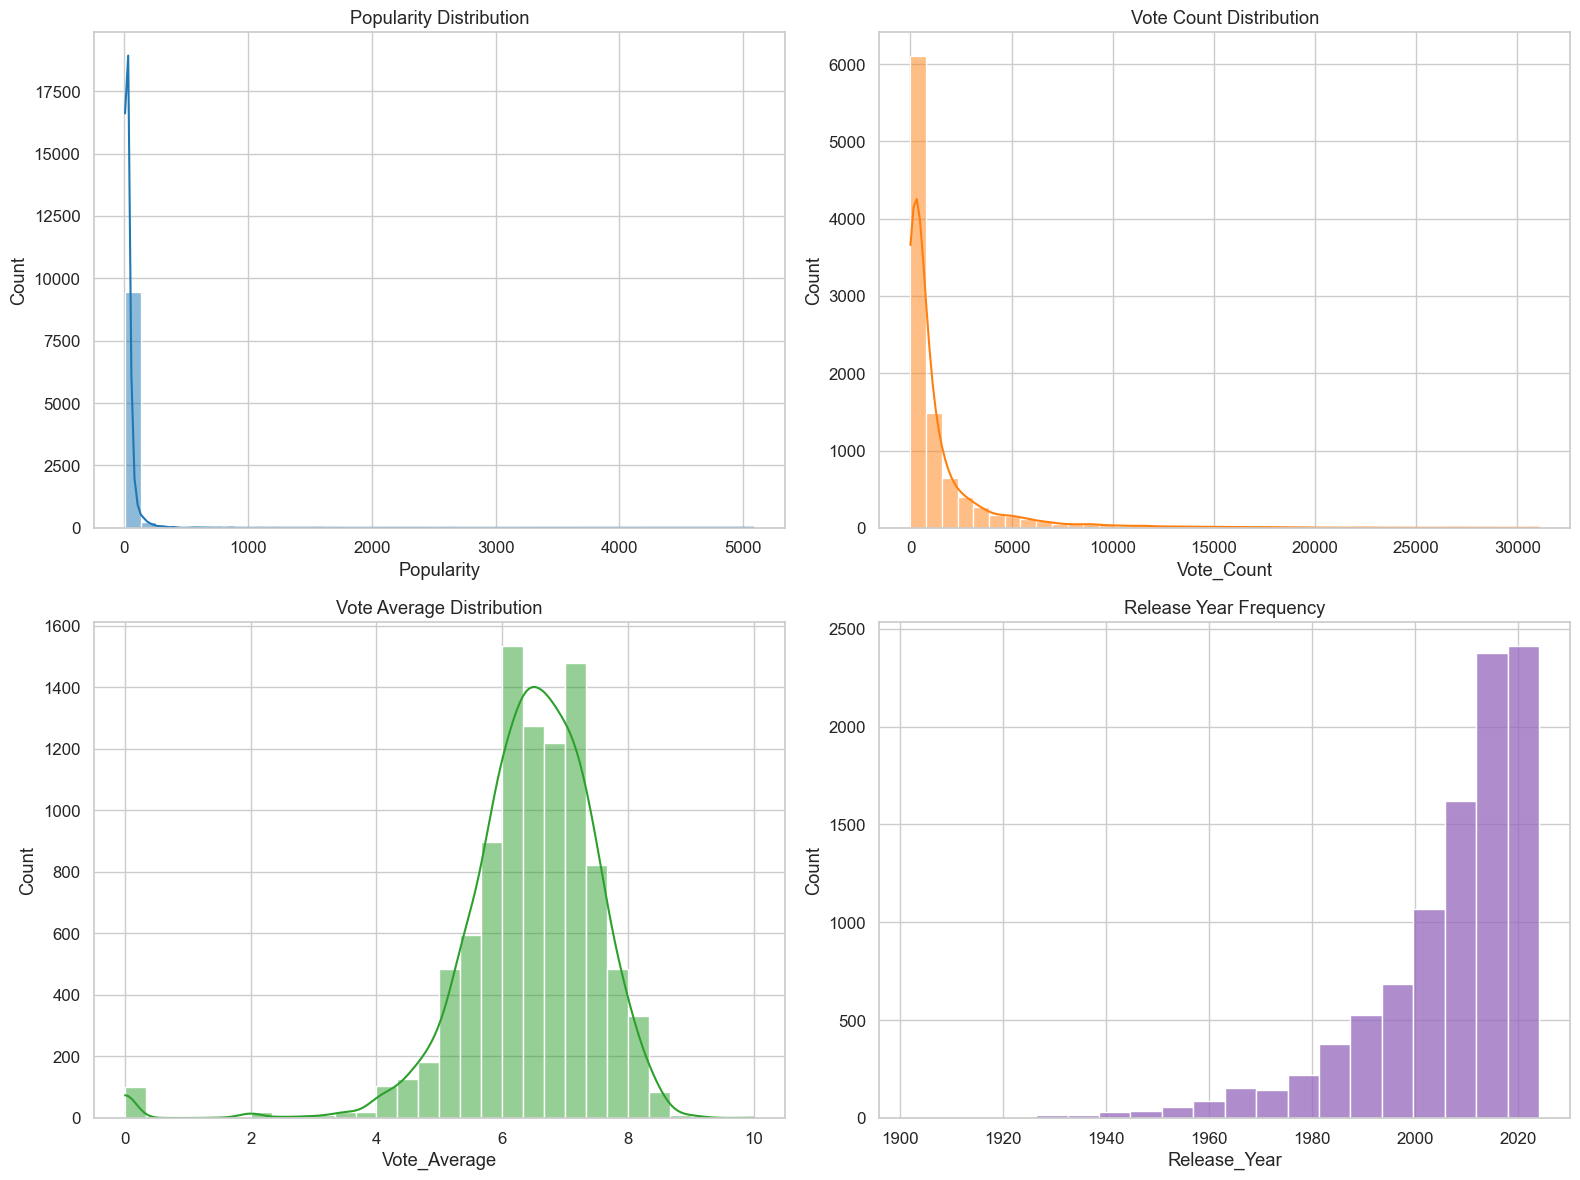

In [3]:
df['Release_Date'] = pd.to_datetime(df['Release_Date'], errors='coerce')
df['Vote_Count'] = pd.to_numeric(df['Vote_Count'], errors='coerce')
df['Vote_Average'] = pd.to_numeric(df['Vote_Average'], errors='coerce')
df['Title_Length'] = df['Title'].fillna('').str.len()
df['Overview_Length'] = df['Overview'].fillna('').str.len()
df['Genre_Count'] = df['Genre'].fillna('').apply(lambda x: len([g for g in x.split(',') if g.strip()]))
df['Release_Year'] = df['Release_Date'].dt.year
df['Release_Month'] = df['Release_Date'].dt.month

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
sns.histplot(df['Popularity'].dropna(), bins=40, ax=axes[0, 0], kde=True, color='tab:blue')
axes[0, 0].set_title('Popularity Distribution')
sns.histplot(df['Vote_Count'].dropna(), bins=40, ax=axes[0, 1], kde=True, color='tab:orange')
axes[0, 1].set_title('Vote Count Distribution')
sns.histplot(df['Vote_Average'].dropna(), bins=30, ax=axes[1, 0], kde=True, color='tab:green')
axes[1, 0].set_title('Vote Average Distribution')
sns.histplot(df['Release_Year'].dropna(), bins=20, ax=axes[1, 1], kde=False, color='tab:purple')
axes[1, 1].set_title('Release Year Frequency')
plt.tight_layout()
plt.show()

### EDA Insights
- `Popularity` and `Vote_Count` are skewed, with a small number of movies achieving very high popularity or vote volume.
- `Vote_Average` is concentrated in the mid-range, which is suitable for regression modeling.
- Most records are recent releases, so date-based features should help capture temporal patterns.

C:\Users\Sarvagya\AppData\Local\Temp\ipykernel_5676\2845333108.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_languages.values, y=top_languages.index, ax=axes[0], palette='viridis')
C:\Users\Sarvagya\AppData\Local\Temp\ipykernel_5676\2845333108.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_genres.values, y=top_genres.index, ax=axes[1], palette='magma')


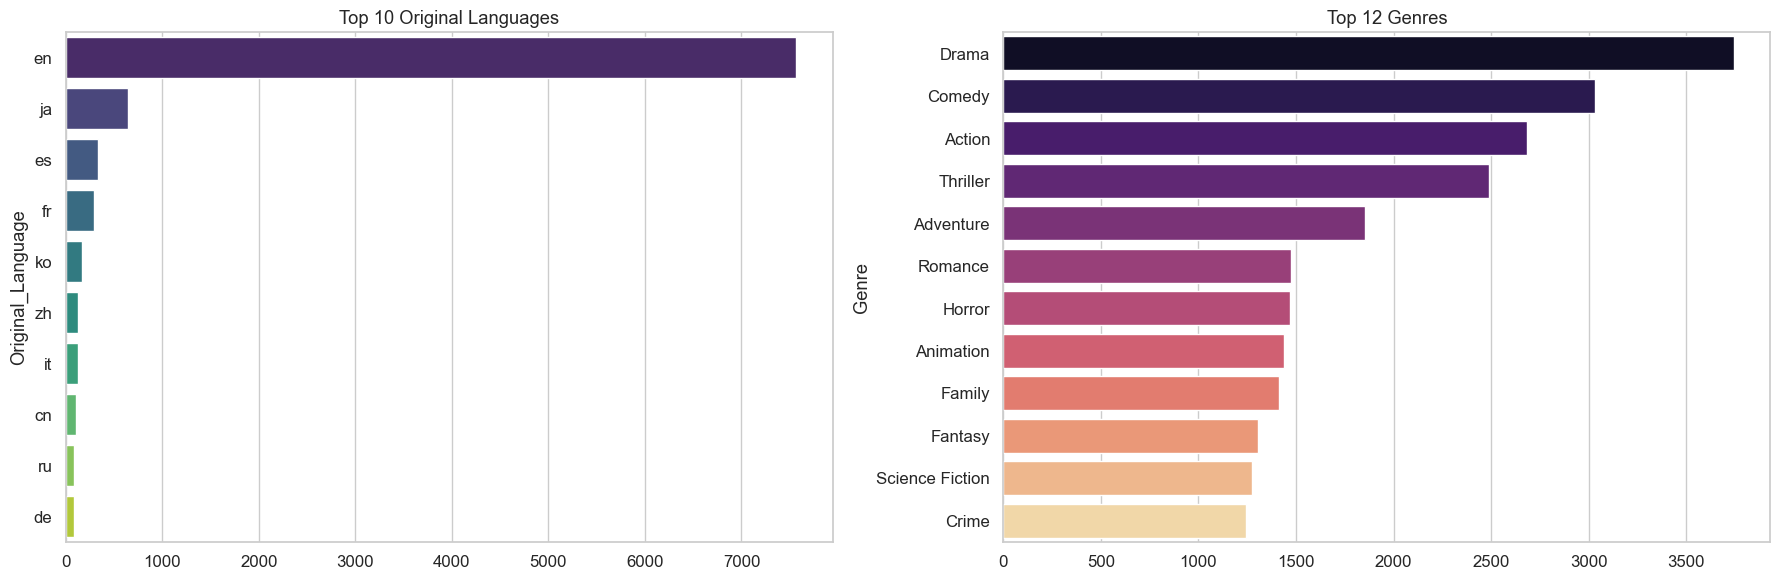

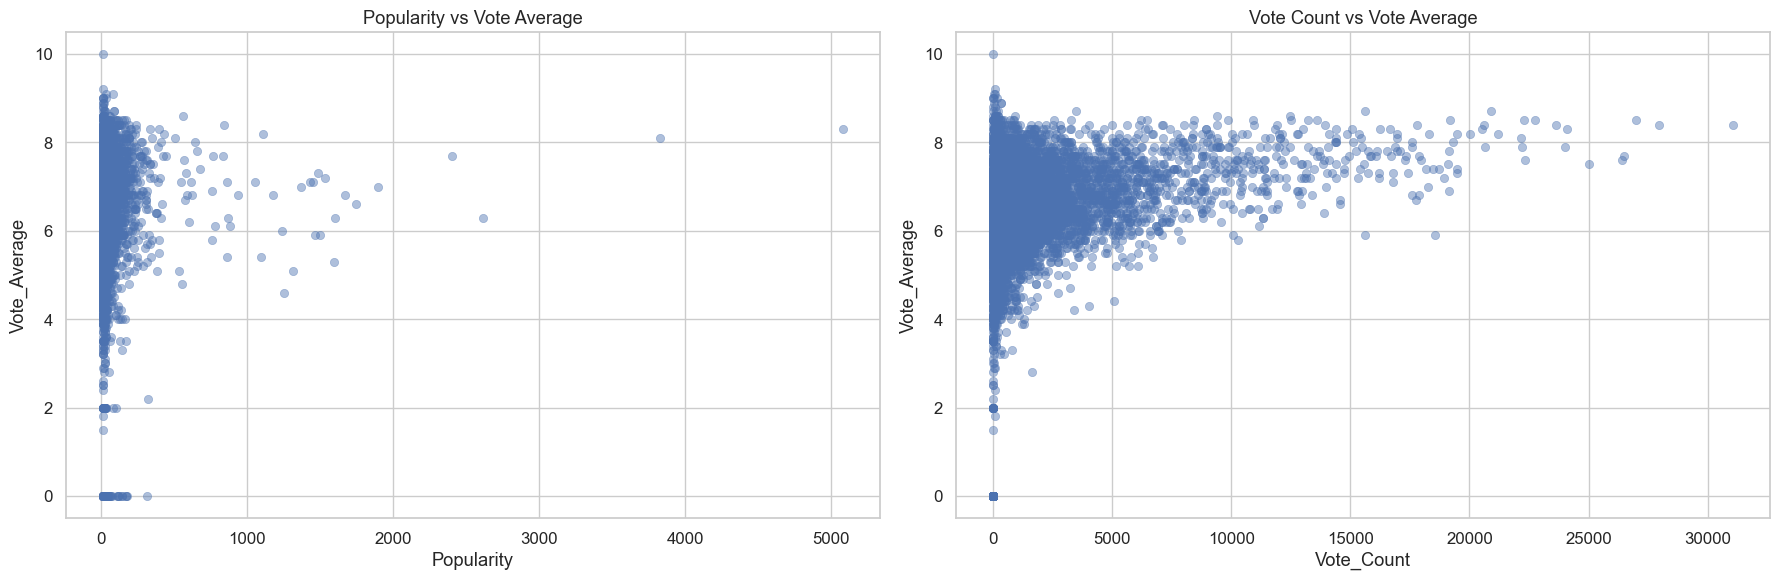

In [4]:
top_languages = df['Original_Language'].value_counts().head(10)
top_genres = df['Genre'].dropna().str.split(',').explode().str.strip().value_counts().head(12)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
sns.barplot(x=top_languages.values, y=top_languages.index, ax=axes[0], palette='viridis')
axes[0].set_title('Top 10 Original Languages')
sns.barplot(x=top_genres.values, y=top_genres.index, ax=axes[1], palette='magma')
axes[1].set_title('Top 12 Genres')
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
sns.scatterplot(data=df, x='Popularity', y='Vote_Average', alpha=0.45, ax=axes[0], edgecolor=None)
axes[0].set_title('Popularity vs Vote Average')
sns.scatterplot(data=df, x='Vote_Count', y='Vote_Average', alpha=0.45, ax=axes[1], edgecolor=None)
axes[1].set_title('Vote Count vs Vote Average')
plt.tight_layout()
plt.show()

### Genre and Rating Analysis
- The most frequent genres and languages provide strong contextual signals for movie ratings.
- Popularity and vote count are positively related to average rating, but the relationship is not perfectly linear.
- This motivates adding genre, language, and date-based features in preprocessing.

## Preprocessing and Feature Engineering
We will build regression features from metadata and categorical fields. The preprocessing plan includes:
1. Converting numeric values to proper types.
2. Extracting year and month from release date.
3. Creating text length and genre count features.
4. Encoding the most frequent languages and genres.
5. Dropping any rows missing essential predictors or the target.

In [5]:
clean = df.copy()
clean = clean.dropna(subset=['Vote_Average', 'Vote_Count', 'Popularity', 'Original_Language', 'Release_Date', 'Genre'])
clean = clean[clean['Vote_Average'].notna()]
clean = clean[clean['Vote_Count'].notna()]

top_language_list = clean['Original_Language'].value_counts().head(10).index.tolist()
for lang in top_language_list:
    clean[f'lang_{lang}'] = (clean['Original_Language'] == lang).astype(int)
clean['lang_other'] = (~clean['Original_Language'].isin(top_language_list)).astype(int)

top_genre_list = clean['Genre'].str.split(',').explode().str.strip().value_counts().head(12).index.tolist()
for genre in top_genre_list:
    safe_genre = genre.replace(' ', '_').replace('-', '_').lower()
    clean[f'genre_{safe_genre}'] = clean['Genre'].fillna('').apply(lambda x: int(genre in [g.strip() for g in x.split(',')]))

feature_columns = [
    'Popularity', 'Vote_Count', 'Release_Year', 'Release_Month', 'Title_Length', 'Overview_Length', 'Genre_Count'
] + [f'lang_{lang}' for lang in top_language_list] + ['lang_other'] + [f'genre_{genre.replace(' ', '_').replace('-', '_').lower()}' for genre in top_genre_list]

X = clean[feature_columns].copy()
y = clean['Vote_Average'].copy()

print('Training dataset shape:', X.shape)
print('Feature columns:', feature_columns)
print('Missing values in X:', X.isna().sum().sum())
X.head(5)

Training dataset shape: (9826, 30)
Feature columns: ['Popularity', 'Vote_Count', 'Release_Year', 'Release_Month', 'Title_Length', 'Overview_Length', 'Genre_Count', 'lang_en', 'lang_ja', 'lang_es', 'lang_fr', 'lang_ko', 'lang_zh', 'lang_it', 'lang_cn', 'lang_ru', 'lang_de', 'lang_other', 'genre_drama', 'genre_comedy', 'genre_action', 'genre_thriller', 'genre_adventure', 'genre_romance', 'genre_horror', 'genre_animation', 'genre_family', 'genre_fantasy', 'genre_science_fiction', 'genre_crime']
Missing values in X: 0


,Popularity,Vote_Count,Release_Year,Release_Month,Title_Length,Overview_Length,Genre_Count,lang_en,lang_ja,lang_es,...,genre_action,genre_thriller,genre_adventure,genre_romance,genre_horror,genre_animation,genre_family,genre_fantasy,genre_science_fiction,genre_crime
0,5083.954,8940.0,2021.0,12.0,23,258,3,1,0,0,...,1,0,1,0,0,0,0,0,1,0
1,3827.658,1151.0,2022.0,3.0,10,162,3,1,0,0,...,0,1,0,0,0,0,0,0,0,1
2,2618.087,122.0,2022.0,2.0,7,259,1,1,0,0,...,0,1,0,0,0,0,0,0,0,0
3,2402.201,5076.0,2021.0,11.0,7,520,4,1,0,0,...,0,0,0,0,0,1,1,1,0,0
4,1895.511,1793.0,2021.0,12.0,14,155,4,1,0,0,...,1,1,1,0,0,0,0,0,0,0


### Preprocessing Summary
The dataset is now ready for training with numeric and categorical metadata features. Genre and language encodings allow the model to capture important content and audience signals.

## Model Training and Evaluation
We will train three regression models and compare their performance on a holdout test set using MAE, MSE, RMSE, and R2 metrics.

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
models = {
    'LinearRegression': Pipeline([('scaler', StandardScaler()), ('model', LinearRegression())]),
    'RandomForest': Pipeline([('scaler', StandardScaler()), ('model', RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1))]),
    'GradientBoosting': Pipeline([('scaler', StandardScaler()), ('model', GradientBoostingRegressor(n_estimators=100, random_state=42))])
}
results = []
for name, pipeline in models.items():
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    results.append({
        'Model': name,
        'MAE': mae,
        'MSE': mse,
        'RMSE': rmse,
        'R2': r2,
    })
    print(f'{name} trained and evaluated.')

results_df = pd.DataFrame(results).set_index('Model')
results_df

LinearRegression trained and evaluated.


RandomForest trained and evaluated.


GradientBoosting trained and evaluated.


,MAE,MSE,RMSE,R2
Model,,,,
LinearRegression,0.626097,0.811603,0.900890,0.255708
RandomForest,0.489248,0.421389,0.649145,0.613560
GradientBoosting,0.510585,0.446931,0.668529,0.590136


C:\Users\Sarvagya\AppData\Local\Temp\ipykernel_5676\2223182497.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=results_df.index, y='MAE', data=results_df.reset_index(), ax=ax[0], palette='Blues_d')
C:\Users\Sarvagya\AppData\Local\Temp\ipykernel_5676\2223182497.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=results_df.index, y='RMSE', data=results_df.reset_index(), ax=ax[1], palette='Greens_d')
C:\Users\Sarvagya\AppData\Local\Temp\ipykernel_5676\2223182497.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=results_df.index, y=

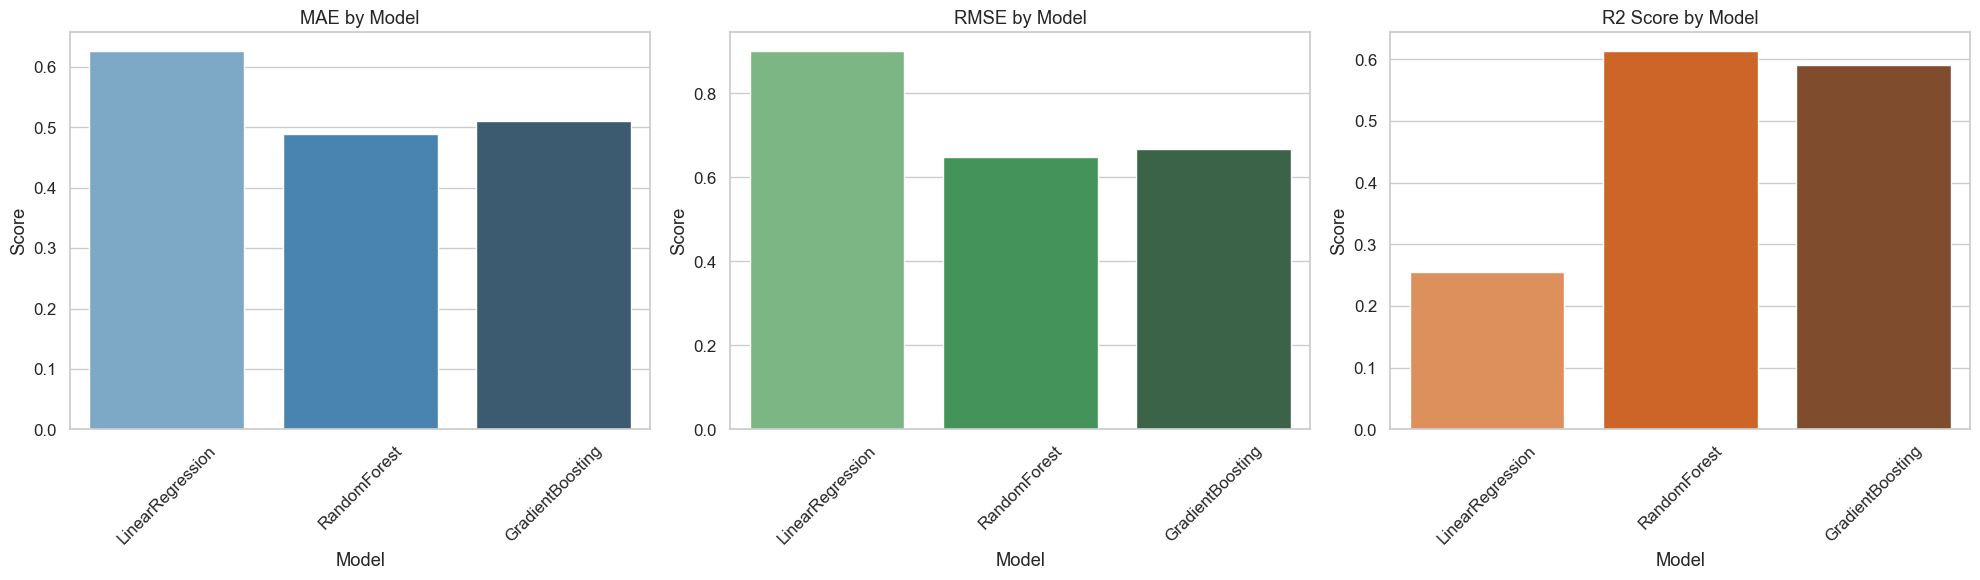

In [7]:
fig, ax = plt.subplots(1, 3, figsize=(20, 6))
sns.barplot(x=results_df.index, y='MAE', data=results_df.reset_index(), ax=ax[0], palette='Blues_d')
ax[0].set_title('MAE by Model')
sns.barplot(x=results_df.index, y='RMSE', data=results_df.reset_index(), ax=ax[1], palette='Greens_d')
ax[1].set_title('RMSE by Model')
sns.barplot(x=results_df.index, y='R2', data=results_df.reset_index(), ax=ax[2], palette='Oranges_d')
ax[2].set_title('R2 Score by Model')
for axis in ax:
    axis.set_xlabel('Model')
    axis.set_ylabel('Score')
    axis.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

### Model Comparison and Interpretation
- LinearRegression provides a transparent baseline but underperforms here, with MAE ~0.626, RMSE ~0.901, and R2 ~0.256.
- RandomForest achieved the best results, with MAE ~0.489, RMSE ~0.649, and R2 ~0.614, indicating it captures the nonlinear structure in the data most effectively.
- GradientBoosting also performs well, with MAE ~0.511, RMSE ~0.669, and R2 ~0.590, but it is slightly behind the RandomForest in this case.

The results show that tree-based ensembles are more effective than a simple linear model for this movie rating prediction task, likely because they can model interactions between popularity, vote count, release timing, genre, and language.

## Final Analysis and Next Steps
- The executed results show RandomForest is the strongest model for this dataset, with the lowest MAE and RMSE and the highest R2 score.
- GradientBoosting is a close second, and both tree-based methods outperform LinearRegression, confirming that movie rating prediction benefits from nonlinear modeling.
- The feature set of popularity, vote count, release date, genre, and language provides useful predictive signal, but there is still room to improve with additional data enrichment.
- Next steps could include hyperparameter tuning for the best model, text-based feature extraction from Overview, and richer handling of rare genres or languages to capture more nuance in movie ratings.